In [1]:
import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')  # Enable TF32 for ~2x speedup
# For fast training, set 'BOS_TOKEN_ID' to 15 in 'sorl/gat_sim.py' 

gat_config = GATConfig(
    vocab_sizes=[BOS_TOKEN_ID+1, 6],  # 6 abstract tokens
    n_layer=4,
    n_head=4,
    n_embd=128,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

model = GAT(gat_config)
# model = model.to("cuda")
# model = torch.compile(model)

In [2]:
# ---- Copy & Paste Data Loader ----
from data.copy_paste import CopyPasteDataLoader

seq_len = 16
loader = CopyPasteDataLoader(vocab_size=16, max_token=10, seq_len=seq_len, device='cpu')
tokens, loss_mask = loader.get_batch(2)

(Exploration). Simplified Group Preference Optimization (SGPO) + Topological Similarity regularization
$$
\begin{align*}
&\mathcal{L}_{SGPO\,\,TOPO}(s, a_{i}) := \frac{\hat{p}_{\theta}(s | a_{i}) - \text{mean}(\hat{p}_{\theta}(s | a_{1:n}))}{\text{std}(\hat{p}_{\theta}(s | a_{1:n}))}\hat{p}_{\theta}(s | a) + \alpha \cdot \hat{p}_{\theta}(a | s) + \beta \cdot \mathcal{L}_{topo}(s, a_{1:n}) \\
&a_{i} \sim \hat{p}_{\theta}(a | s) \\
&\theta = \theta - {d\mathcal{L}_{SGPO}(s, a_{i})}/{d \theta} \quad \text{for } i \in \{1,2,\dots, n\}\\
\end{align*}
$$
Leads to emergent abstraction structure (unstable)

In [ ]:
# Issue #1. 
# Contrast loss should be done on 'abs wte' instead of 'all wtes' 
# Fix #1. 
# Fixed contrast loss, need to double check its effect with experiments. (On SGPO for a start, when on various adv mode)

torch.Size([6, 128])

In [3]:
from sorl.neo_utils import sorl_search_v4, compute_sgpo_loss_v2, sorl_evaluate_v2, compute_vocab_utilization_rate, compute_loss
from sorl.topo import uniformity_loss, contrastive_loss
from sorl.neo_utils import RunningRewardScaler
from sorl.gapt import GatedPhaseTransition
import copy
from collections import defaultdict

# ------ SGPO + Topo regularization for emerging compositional abstraction structure -------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)
scaler = RunningRewardScaler()

batch_size = 16
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
alpha_loss = 0.1
alpha_topo = 0.0
alpha_contrast = 1.0
adv_mode = 0 # SGPO
topo_mode = 0 # correlation target 
util_dist_mode = 1 # stop grad on worse rollout
n = 2
min_temperature = 0.0
min_train_temperature = 2.0
max_temperature = 5.0
temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
n_eval = 2 
temperatures_eval = torch.tensor([min_temperature, max_temperature], device=model.device)
temperatures_topo = torch.tensor([min_train_temperature, min_train_temperature], device=model.device)
K = 4
max_iterations = 2
num_steps = 500
gapt = GatedPhaseTransition()

record = defaultdict(list)
vocab_util = 1.0
for step in range(num_steps): 

    memory_span = 1792
 
    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv, abs_dist = sorl_search_v4(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                                         mode=adv_mode, truncate_seq_len=False)
    # --- compute loss ---
    traj_loss, grpo_loss, topo_loss = compute_sgpo_loss_v2(search_tokens, search_adv, abs_dist, model, memory_span, attn_blocksize, topo_mode, util_dist_mode)    

    # contrast_loss = contrastive_loss(model.transformer.wte.weight[model.vocab_sizes[0]:])
    contrast_loss = uniformity_loss(model.transformer.wte.weight[model.vocab_sizes[0]:])

    # loss = gapt.step(traj_loss, alpha_loss * abs_loss, verbose=True)
    loss = traj_loss + alpha_loss * grpo_loss + alpha_topo * topo_loss + alpha_contrast * contrast_loss
    # loss = alpha_loss * grpo_loss + alpha_topo * topo_loss # move with curiosity, built with structure
    print("scaled topo loss: ", alpha_topo * topo_loss.item(), "contrast loss: ", contrast_loss.item(), "traj loss: ", traj_loss.item(), "grpo loss: ", grpo_loss.item())

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, max_temperature], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss, topo_sim_greedy = sorl_evaluate_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            _, _, _, _, topo_sim = sorl_evaluate_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_topo,
                                                                     truncate_seq_len=False)
            traj_loss, abs_loss = compute_loss(val_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['traj_loss'].append(traj_loss.item())
            # record['alpha_loss'].append(alpha_loss)
            # record['topo_sim'].append(topo_sim.item())
            # record['topo_sim_greedy'].append(topo_sim_greedy.item())
            record['contrast_loss'].append(contrast_loss.item())
        print(f"\nvalidation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | topo_sim: {topo_sim.item():.2f} | contrast_loss: {contrast_loss.item():.2f}")

scaled topo loss:  -0.0 contrast loss:  -3.807020664215088 traj loss:  3.295837163925171 grpo loss:  0.0

validation step 0 | traj_loss: 3.26 | abs_loss: 3.32 | search adv: -0.01% | vocab util: 83.33% | topo_sim: 0.01 | contrast_loss: -3.81
scaled topo loss:  -0.0 contrast loss:  -3.810142755508423 traj loss:  3.2694027423858643 grpo loss:  -0.00011866539716720581
scaled topo loss:  -0.0 contrast loss:  -3.8132598400115967 traj loss:  3.2089948654174805 grpo loss:  -0.00010063685476779938

validation step 2 | traj_loss: 3.11 | abs_loss: 3.41 | search adv: 0.01% | vocab util: 66.67% | topo_sim: 0.08 | contrast_loss: -3.81
scaled topo loss:  -0.0 contrast loss:  -3.816373109817505 traj loss:  3.1163487434387207 grpo loss:  -0.00041993986815214157
scaled topo loss:  -0.0 contrast loss:  -3.8194820880889893 traj loss:  2.9896509647369385 grpo loss:  7.327552884817123e-05

validation step 4 | traj_loss: 2.86 | abs_loss: 3.67 | search adv: 0.04% | vocab util: 50.00% | topo_sim: 0.13 | contra

In [ ]:
# Fixed contrastive loss on 'abs wte' instead of 'all wtes'
# --------------------------------------------------------
# (1). SGPO + contrastive loss (1.0) --> similar behavior (contrast loss at 1.45), search_adv ~1.% (oscilate -10% - 2%)
# (2). SGPO + normalization loss (1.0) --> similar behaviro

In [1]:
# save model checkpoint
import torch

checkpoint_path = "gat_model.pt"
# torch.save(model.state_dict(), checkpoint_path)
# print(f"Model saved to {checkpoint_path}")


# load model checkpoint
ema_model = GAT(gat_config)
ema_model.load_state_dict(torch.load(checkpoint_path, map_location=ema_model.device))
ema_model.eval()
print(f"Model loaded from {checkpoint_path}")


# child model inherits same parameter, but have its abstraction wte & lm_head re-initialized
from sorl.neo_utils import reinit_model

model.load_state_dict(torch.load(checkpoint_path, map_location=model.device))
# reinit_model(model, mode=0) # re-init abs wte & lm_head
# reinit_model(model, mode=4) # re-init all parameters | this is not aligned with model = GAT(gat_config) intiialization, we get different initial traj_loss

NameError: name 'GAT' is not defined

In [15]:
# -----------------
# Distillation runs
# -----------------

from sorl.neo_utils import sorl_search_v3, sorl_search_v4, compute_sgpo_loss_v2, sorl_evaluate_v2, compute_vocab_utilization_rate, compute_loss, compute_weighted_loss
from sorl.topo import uniformity_loss, contrastive_loss
from sorl.gapt import GatedPhaseTransition
import copy
from collections import defaultdict

# ------ Off-line Distillation Runs -------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)

batch_size = 16
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
alpha_loss = 0.1
alpha_topo = 0.0
adv_mode = 0 # exploitation
topo_mode = 0 # correlation target 
util_dist_mode = 1 # stop grad on worse rollout
n = 2
min_temperature = 0.0
topo_temperature = 2.0
max_temperature = 5.0
temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
n_eval = 2 
temperatures_eval = torch.tensor([min_temperature, max_temperature], device=model.device)
temperatures_topo = torch.tensor([topo_temperature, topo_temperature], device=model.device)
K = 4
max_iterations = 2
num_steps = 200
gapt = GatedPhaseTransition()

record = defaultdict(list)
vocab_util = 1.0
for step in range(num_steps): 

    memory_span = 1792
 
    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv, abs_dist = sorl_search_v4(tokens, ema_model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                                         mode=adv_mode, truncate_seq_len=False)
    # --- compute loss ---
    # traj_loss, abs_loss = compute_loss(search_tokens, model, memory_span, attn_blocksize)
    traj_loss, abs_loss = compute_weighted_loss(search_tokens, search_adv, model, memory_span, attn_blocksize)
    loss = traj_loss + alpha_loss * abs_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, max_temperature], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss, topo_sim_greedy = sorl_evaluate_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            _, _, _, _, topo_sim = sorl_evaluate_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_topo,
                                                                     truncate_seq_len=False)
            # contrast_loss = uniformity_loss(contrastive_loss(model.transformer.wte.weight[model.vocab_sizes[0]:]))
            contrast_loss = contrastive_loss(model.transformer.wte.weight[model.vocab_sizes[0]:])
            traj_loss, abs_loss = compute_loss(val_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['traj_loss'].append(traj_loss.item())
            # record['alpha_loss'].append(alpha_loss)
            # record['topo_sim'].append(topo_sim.item())
            # record['topo_sim_greedy'].append(topo_sim_greedy.item())
            # record['contrast_loss'].append(contrast_loss.item())
        print(f"\nvalidation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | topo_sim: {topo_sim.item():.2f} | contrast_loss: {contrast_loss.item():.2f}")




validation step 0 | traj_loss: 1.13 | abs_loss: 9.18 | search adv: -1.99% | vocab util: 50.00% | topo_sim: 0.05 | contrast_loss: 1.58

validation step 2 | traj_loss: 1.15 | abs_loss: 9.10 | search adv: -1.29% | vocab util: 50.00% | topo_sim: 0.04 | contrast_loss: 1.58

validation step 4 | traj_loss: 1.19 | abs_loss: 10.10 | search adv: -4.07% | vocab util: 66.67% | topo_sim: 0.02 | contrast_loss: 1.58

validation step 6 | traj_loss: 1.19 | abs_loss: 9.44 | search adv: -4.99% | vocab util: 50.00% | topo_sim: 0.01 | contrast_loss: 1.58

validation step 8 | traj_loss: 1.27 | abs_loss: 9.27 | search adv: -3.19% | vocab util: 50.00% | topo_sim: 0.05 | contrast_loss: 1.58

validation step 10 | traj_loss: 1.33 | abs_loss: 9.04 | search adv: -4.25% | vocab util: 33.33% | topo_sim: 0.05 | contrast_loss: 1.58

validation step 12 | traj_loss: 1.39 | abs_loss: 9.06 | search adv: -0.80% | vocab util: 33.33% | topo_sim: 0.04 | contrast_loss: 1.58

validation step 14 | traj_loss: 1.50 | abs_loss: 9.

In [ ]:
# Local experiment suggests 're-init' from scratch produces better 'search_adv' compared to 're-init' wte & lm_head only runs

# Idea #1. --> distill from a randomly initialized model. Locally this improves search adv, on LM experiments benefit disappears. 

# Issue #4. 
# - however, on server side, we did not observe search advantage being very positive. It's below 0% on the runs ... so what's missing? 
# To break down the problem, we can "store" checkpoint of the model (after SGPO), and load it into a separated 'distillation' script. 

# --- (a). load SGPO checkpoint, and do ablation on exploitation procedure on language modeling task --- 

# Idea #2. If we apply adv to both utility & predictability, can we improve search adv on greedy abstraction? 
# -- nope, locally we observe failure in improving search_adv --- they degrade utility. 

# THe main issue, is 'over-explore', which 
# Idea #3. 
# - during exploration, 

# --- adv applied to both utility & predictability? 
# (a). adv \propto p(s | a)--> this produces search adv ~-5.8%, degrades utility | the picture is not that binary, where we just supress non-picked and encourage
# - SGPO doesn't produce a nice utility landscape, so this is expected
# (b). adv \propto p(a | s) --> also degrades the utility, search adv ~ 0%
# (c). adv \propto 1 / p(a | s)
# (d). adv \propto 1 / p(s | a) -> degrades utility, but then oscillates around 1.8 - 2.0, search adv -700%
# (e). 
 

 # Idea #2. 


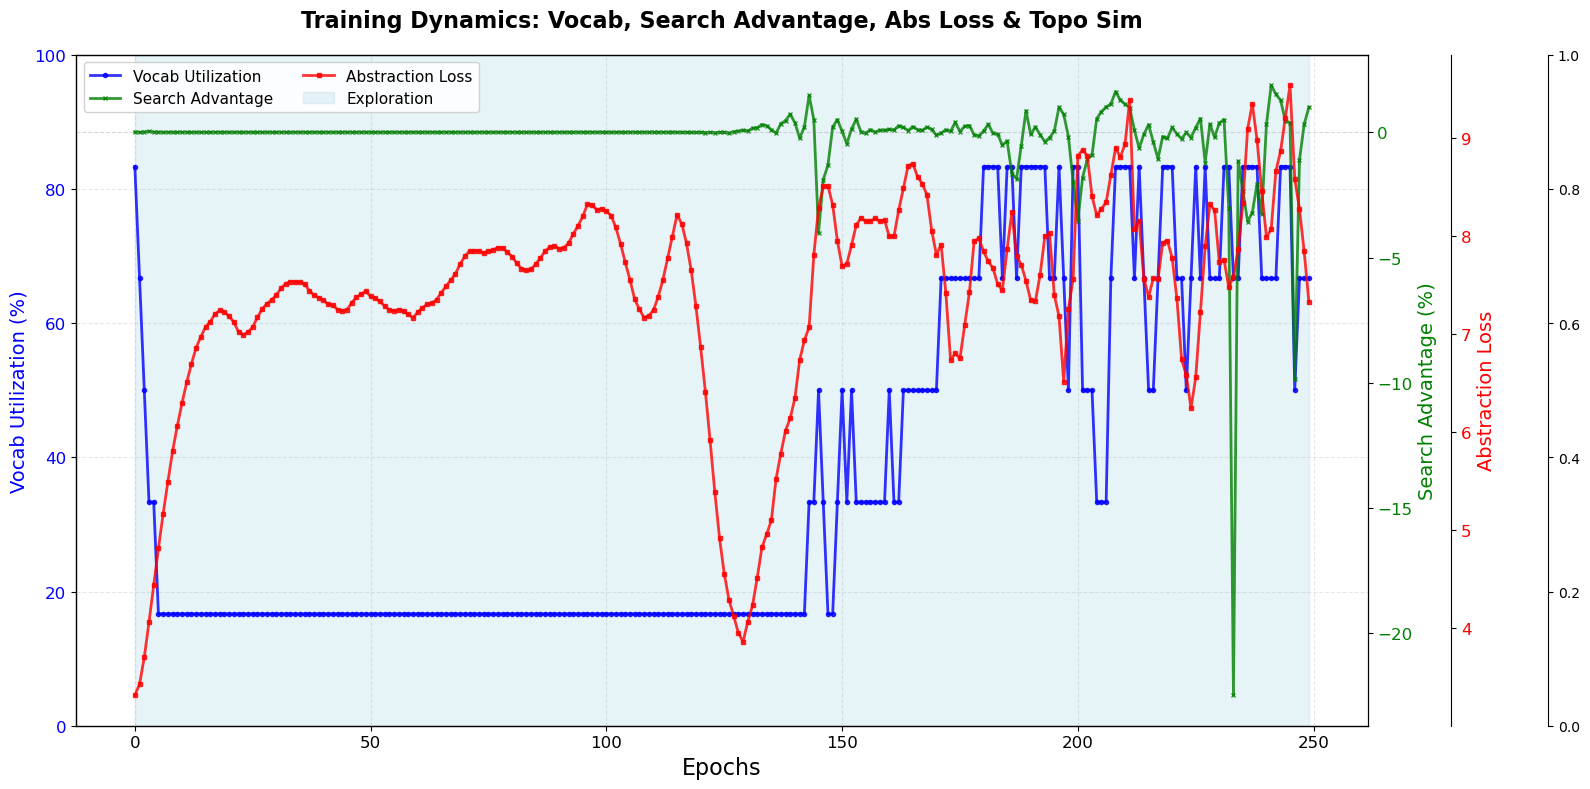

In [4]:
from sorl.stat import plot_training_metrics_combined

plot_training_metrics_combined(record)

In [4]:
# generate function implementation 
# ----------------------------------
from sorl.neo_utils import generate

tokens, loss_mask = loader.get_batch(1)
idx = tokens[:, :1 + seq_len].clone()
print(f"init   | idx: {idx[0].tolist()}")
for i in range(seq_len): 
    idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=torch.tensor(min_temperature))
    idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
    print(f"step {i+1} idx (abstraction free): {idx_without_abstraction.tolist()}")
    print(f"                         idx : {idx[0].tolist()}")

correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
print(f"Copy correct: {correct_cp}")

init   | idx: [20, 5, 3, 8, 7, 8, 5, 3, 2, 4, 5, 6, 9, 2, 0, 6, 8]
step 1 idx (abstraction free): [20, 5, 3, 8, 7, 8, 5, 3, 2, 4, 5, 6, 9, 2, 0, 6, 8, 5]
                         idx : [20, 5, 3, 8, 7, 24, 8, 5, 3, 2, 24, 4, 5, 6, 9, 24, 2, 0, 6, 8, 24, 5]
step 2 idx (abstraction free): [20, 5, 3, 8, 7, 8, 5, 3, 2, 4, 5, 6, 9, 2, 0, 6, 8, 5, 3]
                         idx : [20, 5, 3, 8, 7, 24, 8, 5, 3, 2, 24, 4, 5, 6, 9, 24, 2, 0, 6, 8, 24, 5, 3]
step 3 idx (abstraction free): [20, 5, 3, 8, 7, 8, 5, 3, 2, 4, 5, 6, 9, 2, 0, 6, 8, 5, 3, 8]
                         idx : [20, 5, 3, 8, 7, 24, 8, 5, 3, 2, 24, 4, 5, 6, 9, 24, 2, 0, 6, 8, 24, 5, 3, 8]
step 4 idx (abstraction free): [20, 5, 3, 8, 7, 8, 5, 3, 2, 4, 5, 6, 9, 2, 0, 6, 8, 5, 3, 8, 7]
                         idx : [20, 5, 3, 8, 7, 24, 8, 5, 3, 2, 24, 4, 5, 6, 9, 24, 2, 0, 6, 8, 24, 5, 3, 8, 7]
step 5 idx (abstraction free): [20, 5, 3, 8, 7, 8, 5, 3, 2, 4, 5, 6, 9, 2, 0, 6, 8, 5, 3, 8, 7, 8]
                         idx : [20, 5,

In [ ]:
from sorl.eval import compute_vocab_utilization_rate

def eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, temperature=torch.tensor(0.5), num_samples=100):
    n_correct = 0
    abs_idx = []
    for _ in range(num_samples): 
        tokens, loss_mask = loader.get_batch(1)
        idx = tokens[:, :1 + seq_len].clone()
        for i in range(seq_len): 
            idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=temperature)
            idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
            abs_idx.append(idx[idx >= model.vocab_sizes[0]])
        correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
        n_correct += correct_cp
    acc = n_correct / num_samples
    print(f"=== Copy & Paste Evaluation ===\n Copy correct: {acc * 100:.2f}%")

    data = torch.cat(abs_idx, dim=0)
    abs_util_rate = compute_vocab_utilization_rate(data, model)
    return acc, abs_util_rate


eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, num_samples=20)

=== Copy & Paste Evaluation ===
 Copy correct: 100.00%


(1.0, 0.8333333333333334)

 Total abs tokens: 6 | Unique abs tokens: 1 | Abs util rate: 16.67%


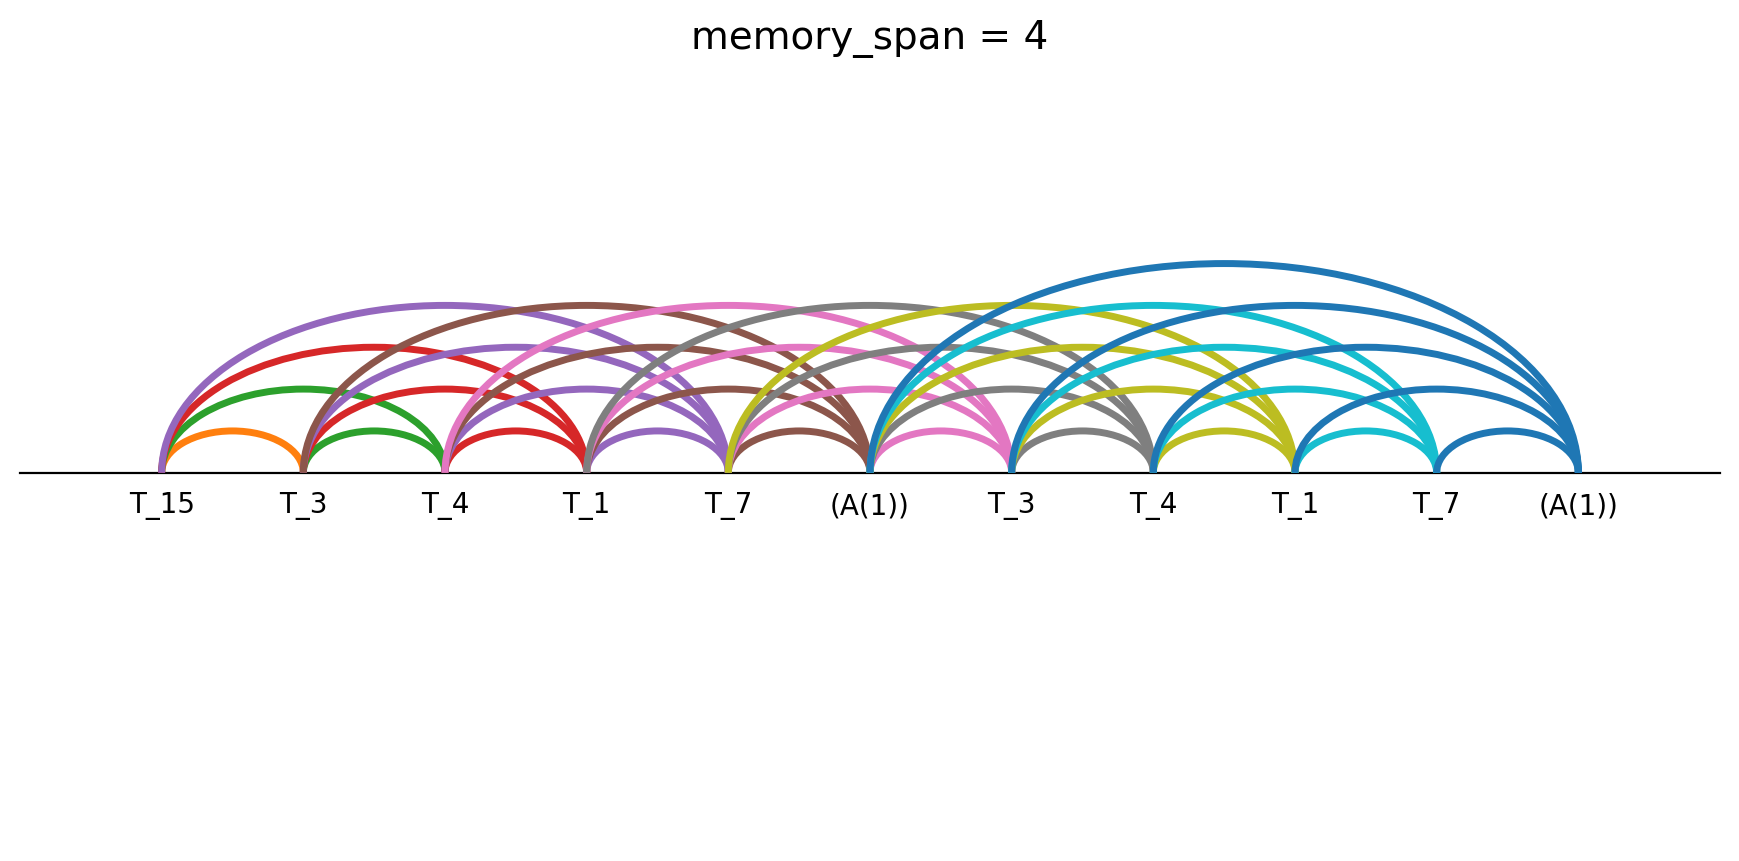

In [ ]:
# Simple 2D Attention Mask (without num_heads dimension)
# ======================================================

import torch
from sorl.neo_utils import sorl_search
from sorl.stat import plot_attn_arcs, materialize_attention_mask, AttentionMaskVisualizer

# Your existing variables
tokens, loss_mask = loader.get_batch(1)
with torch.no_grad(): 
    search_tokens, search_ppt, search_adv = sorl_search(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature,
                                                            truncate_seq_len=False)

# Generate 2D attention mask
levels = (search_tokens >= model.vocab_sizes[0]).long()
attn_mask = materialize_attention_mask(search_tokens, model, memory_span, attn_blocksize=1792)
visualizer = AttentionMaskVisualizer(search_tokens, model, attn_mask)

visualizer.plot_arcs(title=f"memory_span = {memory_span}")


In [ ]:
# heuristic rollout
import os, glob, itertools
from pathlib import Path

# MPS specific data loader functional (single device ver.)
# --------------------------------------------
def _load_data_shard(file: Path):
    header = torch.from_file(str(file), False, 256, dtype=torch.int32) # header is 256 int32
    assert header[0] == 20240520, "magic number mismatch in the data .bin file"
    assert header[1] == 1, "unsupported version"
    num_tokens = int(header[2]) # number of tokens (claimed)
    with file.open("rb", buffering=0) as f:
        tokens = torch.empty(num_tokens, dtype=torch.uint16, pin_memory=False) # MPS requires pin_memory=False
        f.seek(256 * 4)
        nbytes = f.readinto(tokens.numpy()) # avoid bytes->array copy by @YouJiacheng
        assert nbytes == 2 * num_tokens, "number of tokens read does not match header"
    return tokens

def data_generator(filename_pattern: str, sequence_length: int, device: str): 

    filename_pattern = "data/fineweb10B/fineweb_train_*.bin"
    files = [Path(file) for file in sorted(glob.glob(filename_pattern))]
    file_iter = itertools.cycle(files)
    tokens, pos = _load_data_shard(next(file_iter)), 0
    while True: 
        # Concern 1. Doesn't this means end-of-file is never reached?
        if pos + sequence_length + 1 >= len(tokens): # not enough data left -> load a new file
            tokens, pos = _load_data_shard(next(file_iter)), 0

        idx = tokens[pos : pos + sequence_length + 1].unsqueeze(0).to(device=device, dtype=torch.int32, non_blocking=True)
        pos += sequence_length
        yield idx


data = _load_data_shard(Path("data/fineweb10B/fineweb_train_000002.bin"))

train_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_train_*.bin", sequence_length=256, device="cpu")
val_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_val_000000.bin", sequence_length=256, device="cpu")

In [ ]:
from sorl.neo_utils import sorl_search_v2 

n = 2
K = 8
max_iterations=2
memory_span=1792
attn_blocksize=1792
temperature=10.0 

tokens = next(train_loader)

with torch.no_grad(): 
    search_tokens, search_ppt, search_adv, pt_curiosity = sorl_search_v2(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature)

In [ ]:
# --- Benchmark Speed & Memory Cost --- 
from sorl.benchmark import run_benchmark_suite
from sorl.neo_utils import sorl_search_v4
import torch 


# Levenshtein distance computation might've grabbed the majority of time
# --- it's current speed is un-acceptable. 